# 模拟 A/B Test：主指标统计评估

**历史数据没有真实 treatment 或提醒触达。** 本章直接复用 [SQL 07](../sql/07_ab_test_design.sql)，将用户通过固定 MD5 分桶分配标签，演示统计评估流程。组间差异不能解释为购物车召回的因果效果，也不能据此判断提醒有效或无效。

Pre-period：2017-11-25 至 12-01；实验起点：12-02 00:00；Outcome：12-02 至 12-03；时区 Asia/Shanghai。人群仅用前期加购、无购买及最近活跃条件构建；分母包括所有分组用户。

依赖沿用 `requirements.txt`，统计计算使用 Python 标准库 `math` / `statistics.NormalDist`，不新增第三方统计依赖。需先准备本地 DuckDB 数据库，环境与数据步骤见 [README](../README.md#12-如何运行)。

In [1]:
from pathlib import Path
import hashlib
import tempfile
import math
from statistics import NormalDist
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from IPython.display import display, Markdown

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'sql/07_ab_test_design.sql').exists()), None)
if root is None:
    raise FileNotFoundError('请从项目根目录或 notebooks 目录启动。')
sql_path = root / 'sql/07_ab_test_design.sql'
print('SQL SHA256:', hashlib.sha256(sql_path.read_bytes()).hexdigest())
alpha, target_power = 0.05, 0.80
normal = NormalDist()
z_critical = normal.inv_cdf(1-alpha/2)

SQL SHA256: 820e5f902dc97339a110a7fc77d38ba679b7b2dc6b384682378a9dc02fe050bd


## 1. 从数据库复现与核验

执行原 SQL 的全部计算和检查，延迟清理 TEMP 表，读取未舍入分组指标与平衡表；然后清理并关闭只读连接。已验证人数只用于断言，不作为最终计算的数据源。不一致则停止。

In [2]:
with tempfile.TemporaryDirectory(prefix='ecommerce-ab-') as spill_dir:
    con = duckdb.connect(str(root / 'data/processed/ecommerce.duckdb'), read_only=True)
    try:
        con.execute("SET memory_limit='3GB'")
        con.execute('SET threads=4')
        con.execute("SET temp_directory='" + spill_dir.replace("'", "''") + "'")
        cleanup, checks = [], None
        for statement in con.extract_statements(sql_path.read_text()):
            if statement.type == duckdb.StatementType.DROP:
                cleanup.append(statement)
                continue
            result = con.execute(statement)
            if statement.type == duckdb.StatementType.SELECT and result.description[0][0]=='check_name':
                checks = result.fetchdf()
        assert checks is not None and checks['invalid_rows'].eq(0).all(), 'SQL 校验未通过'
        group_metrics = con.execute('SELECT * FROM ab_group_metrics ORDER BY experiment_group').fetchdf()
        balance = con.execute('SELECT * FROM ab_balance ORDER BY metric').fetchdf()
        counts = con.execute('SELECT COUNT(*) AS rows, COUNT(DISTINCT user_id) AS users FROM ab_user_results').fetchone()
        assert counts == (211091, 211091), '实验用户不唯一或总数不一致'
        for statement in cleanup:
            con.execute(statement)
    finally:
        con.close()
metrics = group_metrics.set_index('experiment_group')
assert int(metrics.loc['Treatment','experiment_users']) == 105898
assert int(metrics.loc['Control','experiment_users']) == 105193
assert int(metrics.loc['Treatment','purchase_users']) == 26891
assert int(metrics.loc['Control','purchase_users']) == 26800
assert len(balance)==7 and balance['smd'].notna().all()
assert balance['smd'].abs().lt(.005).all()
display(checks)
print('数据库结果复现与核验通过；未修改源表。')

,check_name,invalid_rows
0,invalid_eligibility,0
1,duplicate_assignment,0
2,assignment_population_mismatch,0
3,invalid_assignment_label,0
4,nonrepeatable_assignment,0
5,pre_window_leakage,0
6,outcome_window_violation,0
7,invalid_window_configuration,0
8,eligibility_feature_mismatch,0
9,invalid_outcome,0


数据库结果复现与核验通过；未修改源表。


## 2. 描述性结果与单位

purchase_user_rate = 两天内至少一次 buy 的用户 / 所有分组用户。

**绝对 lift** 为 `(p_T − p_C) × 100`，单位是 **百分点（percentage points）**；**相对 lift** 为 `(p_T / p_C − 1) × 100`，单位是百分比变化（percentage change）。buy 次数仍是事件数，不是订单数。

In [3]:
n_t = int(metrics.loc['Treatment','experiment_users'])
n_c = int(metrics.loc['Control','experiment_users'])
x_t = int(metrics.loc['Treatment','purchase_users'])
x_c = int(metrics.loc['Control','purchase_users'])
p_t, p_c = x_t/n_t, x_c/n_c
rate_difference = p_t-p_c
absolute_lift_pp = rate_difference*100
relative_lift_pct = (p_t/p_c-1)*100 if p_c>0 else np.nan
result_table = pd.DataFrame({
    '组别':['Treatment','Control'], '用户数':[n_t,n_c], '购买用户数':[x_t,x_c],
    '购买用户率（%）':[p_t*100,p_c*100],
    '后期活跃率（%）':[metrics.loc['Treatment','active_rate']*100,metrics.loc['Control','active_rate']*100],
    '人均购买事件数':[metrics.loc['Treatment','avg_buy_events_per_user'],metrics.loc['Control','avg_buy_events_per_user']]})
display(result_table.round(6))
display(pd.DataFrame({'指标':['绝对 lift（百分点）','相对 lift（%）'],
                      '结果':[absolute_lift_pp,relative_lift_pct]}).round(6))

,组别,用户数,购买用户数,购买用户率（%）,后期活跃率（%）,人均购买事件数
0,Treatment,105898,26891,25.393303,99.903681,0.419035
1,Control,105193,26800,25.476980,99.911591,0.417347


,指标,结果
0,绝对 lift（百分点）,-0.083677
1,相对 lift（%）,-0.328443


## 3. 双比例 z 检验与差值 95% CI

H0：Treatment 与 Control 的购买用户率相等；H1：不相等。双侧检验，alpha = 0.05。

检验使用 H0 下合并比例 `p_pool=(x_T+x_C)/(n_T+n_C)`，`SE0=sqrt(p_pool(1-p_pool)(1/n_T+1/n_C))`，`z=(p_T-p_C)/SE0`。双侧 p-value 为 `erfc(|z|/sqrt(2))`。

差值 CI 使用**未合并方差的正态近似 Wald 区间**：`差值 ± 1.96 × sqrt(p_T(1-p_T)/n_T + p_C(1-p_C)/n_C)`，输出转换为百分点。两组成功/失败数足够大，适合该近似；方法依赖用户级独立 Bernoulli、完整结果记录和固定观察窗口。固定哈希分桶仅用于模拟，不能取代真实实验日志或验证这些业务假设。

In [4]:
assert min(x_t,n_t-x_t,x_c,n_c-x_c)>=10, '正态近似条件不足'
pooled_rate = (x_t+x_c)/(n_t+n_c)
pooled_se = math.sqrt(pooled_rate*(1-pooled_rate)*(1/n_t+1/n_c))
z_statistic = rate_difference/pooled_se
two_sided_p_value = math.erfc(abs(z_statistic)/math.sqrt(2))
reject_h0 = two_sided_p_value < alpha
unpooled_se = math.sqrt(p_t*(1-p_t)/n_t+p_c*(1-p_c)/n_c)
ci_low_pp = (rate_difference-z_critical*unpooled_se)*100
ci_high_pp = (rate_difference+z_critical*unpooled_se)*100
ci_contains_zero = ci_low_pp<=0<=ci_high_pp
display(pd.DataFrame([{'z_statistic':z_statistic,'two_sided_p_value':two_sided_p_value,
                      'alpha':alpha,'reject_H0':reject_h0,
                      'difference_pp':absolute_lift_pp,'CI_low_pp':ci_low_pp,
                      'CI_high_pp':ci_high_pp,'CI_contains_zero':ci_contains_zero}]))
display(Markdown(f'双侧 p-value = **{two_sided_p_value:.4f}**，在 alpha=0.05 下**{"拒绝" if reject_h0 else "未拒绝"} H0**。差值 95% CI 为 **[{ci_low_pp:.4f}, {ci_high_pp:.4f}] 个百分点**，{"包含" if ci_contains_zero else "不包含"} 0。区间涵盖小幅降低与小幅提高，不支持明显组间差异；未拒绝不等于完全相同或通过等效性检验。频率学派 CI 也不表示真实差值有 95% 概率落在该具体区间。'))

,z_statistic,two_sided_p_value,alpha,reject_H0,difference_pp,CI_low_pp,CI_high_pp,CI_contains_zero
0,-0.441395,0.658927,0.05,False,-0.083677,-0.455239,0.287884,True


双侧 p-value = **0.6589**，在 alpha=0.05 下**未拒绝 H0**。差值 95% CI 为 **[-0.4552, 0.2879] 个百分点**，包含 0。区间涵盖小幅降低与小幅提高，不支持明显组间差异；未拒绝不等于完全相同或通过等效性检验。频率学派 CI 也不表示真实差值有 95% 概率落在该具体区间。

## 4. 主指标与平衡可视化

SMD 沿用 SQL 的 `(Treatment 均值 − Control 均值) / sqrt((两组样本方差之和)/2)`。以下同时展示经验参照 ±0.1 和放大区域，以免小差异不可读。|SMD|<0.1 是常用诊断参照，不是随机化成功的统计定律；小 SMD 不证明未观测特征平衡。

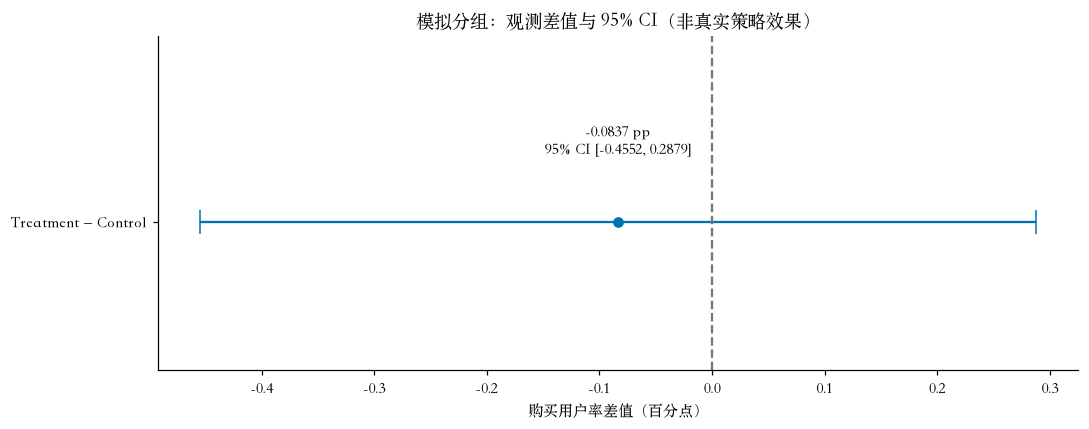

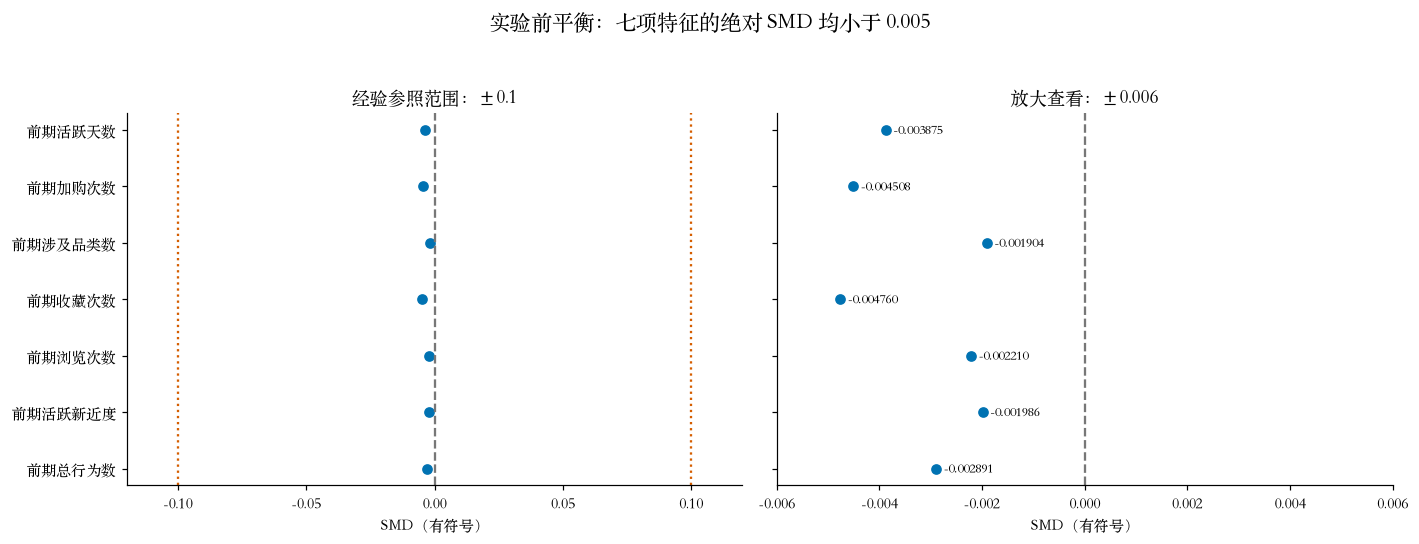

,metric,treatment_mean,control_mean,absolute_difference,smd
0,pre_active_days,5.098519,5.104408,0.005889,-0.003875
1,pre_cart_count,4.886155,4.910422,0.024267,-0.004508
2,pre_category_count,18.554600,18.579155,0.024555,-0.001904
3,pre_fav_count,1.710316,1.737834,0.027519,-0.004760
4,pre_pv_count,63.083977,63.214948,0.130971,-0.002210
5,pre_recency_days,1.182695,1.183463,0.000768,-0.001986
6,pre_total_events,69.680447,69.863204,0.182757,-0.002891


In [5]:
font_paths = [Path('/System/Library/Fonts/PingFang.ttc'),
              Path('/System/Library/Fonts/Supplemental/Songti.ttc'),
              Path('C:/Windows/Fonts/msyh.ttc'),
              Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')]
font_path = next((p for p in font_paths if p.exists()),None)
if font_path:
    font_manager.fontManager.addfont(str(font_path))
    font_name = font_manager.FontProperties(fname=str(font_path)).get_name()
else:
    font_name = next((name for name in ['Noto Sans CJK SC','Microsoft YaHei','SimHei','PingFang SC']
                     if any(f.name==name for f in font_manager.fontManager.ttflist)),None)
if not font_name:
    raise RuntimeError('请安装可用中文字体后再绘图。')
plt.rcParams.update({'font.family':font_name,'axes.unicode_minus':False,
                     'figure.dpi':110,'savefig.dpi':180,'axes.spines.top':False,'axes.spines.right':False})
figure_dir = root/'reports/figures'
figure_dir.mkdir(parents=True,exist_ok=True)
def save_chart(fig,filename):
    fig.savefig(figure_dir/filename,bbox_inches='tight',facecolor='white')
    plt.show()
    plt.close(fig)
fig,ax = plt.subplots(figsize=(10,4))
ax.errorbar([absolute_lift_pp],[0],xerr=[[absolute_lift_pp-ci_low_pp],[ci_high_pp-absolute_lift_pp]],
            fmt='o',capsize=8,color='#0072B2')
ax.axvline(0,color='#777777',linestyle='--')
ax.set(yticks=[0],yticklabels=['Treatment − Control'],xlabel='购买用户率差值（百分点）',
       title='模拟分组：观测差值与 95% CI（非真实策略效果）')
ax.text(absolute_lift_pp,.18,f'{absolute_lift_pp:.4f} pp\n95% CI [{ci_low_pp:.4f}, {ci_high_pp:.4f}]',ha='center')
ax.set_ylim(-.4,.5)
fig.tight_layout()
save_chart(fig,'09_ab_purchase_rate_ci.png')
feature_labels={'pre_pv_count':'前期浏览次数','pre_fav_count':'前期收藏次数','pre_cart_count':'前期加购次数',
                'pre_total_events':'前期总行为数','pre_active_days':'前期活跃天数',
                'pre_category_count':'前期涉及品类数','pre_recency_days':'前期活跃新近度'}
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True)
for ax,limit,title in zip(axes,[.12,.006],['经验参照范围：±0.1','放大查看：±0.006']):
    ax.scatter(balance['smd'],range(len(balance)),color='#0072B2')
    ax.axvline(0,color='#777777',linestyle='--')
    ax.set(xlim=(-limit,limit),yticks=range(len(balance)),
           yticklabels=[feature_labels[x] for x in balance['metric']],xlabel='SMD（有符号）',title=title)
    ax.invert_yaxis() if not ax.yaxis_inverted() else None
axes[0].axvline(-.1,color='#D55E00',linestyle=':')
axes[0].axvline(.1,color='#D55E00',linestyle=':')
for i,smd in enumerate(balance['smd']):axes[1].text(smd+.00015,i,f'{smd:.6f}',va='center',fontsize=9)
fig.suptitle('实验前平衡：七项特征的绝对 SMD 均小于 0.005',fontsize=14)
fig.tight_layout(rect=(0,0,1,.94))
save_chart(fig,'10_ab_preperiod_smd.png')
display(balance.round(6))

**图表解释：**差值区间跨越 0，反映估计的不确定性。SMD 图说明当前已观测均值差异较小，不验证真实提醒送达、用户干扰或未观测因素。

## 5. Power、样本量与 MDE

使用数据库读取的 Control 购买用户率（约 25.48%）作为**规划假设**，alpha=0.05、power=0.80、双侧、1:1 分配。不是用观测 lift 当成未来预期效果，也不计算“事后 observed power”。

采用双比例大样本正态近似，未做连续性校正。对于每组 n、baseline p0、目标 p1=p0+delta：

- H0 临界差值 `c=z_(1-alpha/2) × sqrt(2*p_bar*(1-p_bar)/n)`，`p_bar=(p0+p1)/2`。
- H1 下差值近似 `N(delta, [p0(1-p0)+p1(1-p1)]/n)`。
- power 为该分布落在 `(-∞,-c)` 或 `(c,+∞)` 的概率，两侧均计入。

通过二分求解最小整数样本量。该近似适用于本章大样本设计，真实实验还应考虑基线变化、流量与送达、用户相关性、失访以及护栏指标。

,目标绝对 uplift（百分点）,每组所需用户,合计用户,近似 power
0,0.5,119981,239962,0.800000
1,1.0,30184,60368,0.800002
2,2.0,7639,15278,0.800032


以每组 **105,193** 人作保守等量近似，正向绝对 MDE 约为 **0.5341 个百分点**，对应相对变化约 **2.10%**。MDE 是既定 alpha/power 假设下的最小可检测效应，不是预期效果、业务目标或置信区间界限；它不保证每次实验一定检出该大小的差异。

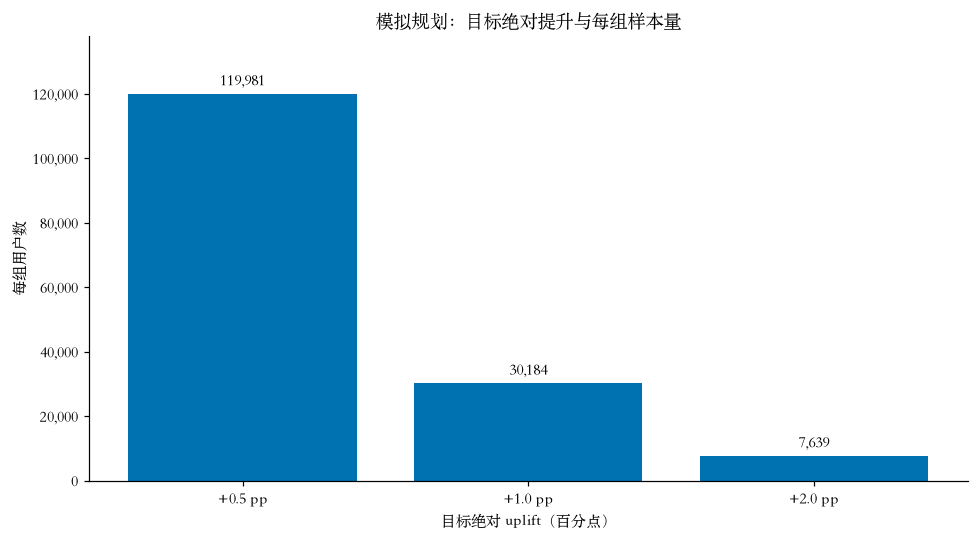

In [6]:
def normal_approx_power(n_per_arm,baseline_rate,absolute_uplift):
    alternative_rate=baseline_rate+absolute_uplift
    if not (0<baseline_rate<alternative_rate<1):
        raise ValueError('需要 0 < baseline < alternative < 1')
    mean_rate=(baseline_rate+alternative_rate)/2
    critical_difference=z_critical*math.sqrt(2*mean_rate*(1-mean_rate)/n_per_arm)
    alternative_se=math.sqrt((baseline_rate*(1-baseline_rate)+alternative_rate*(1-alternative_rate))/n_per_arm)
    lower_tail=normal.cdf((-critical_difference-absolute_uplift)/alternative_se)
    upper_tail=normal.cdf((absolute_uplift-critical_difference)/alternative_se)
    return lower_tail+upper_tail

def required_sample_size(baseline_rate,absolute_uplift,power=target_power):
    low,high=2,2
    while normal_approx_power(high,baseline_rate,absolute_uplift)<power:
        high*=2
    while low<high:
        middle=(low+high)//2
        if normal_approx_power(middle,baseline_rate,absolute_uplift)>=power:high=middle
        else:low=middle+1
    return low

sample_rows=[]
for uplift_pp in [.5,1.,2.]:
    n_required=required_sample_size(p_c,uplift_pp/100)
    assert normal_approx_power(n_required,p_c,uplift_pp/100)>=target_power
    assert normal_approx_power(n_required-1,p_c,uplift_pp/100)<target_power
    sample_rows.append({'目标绝对 uplift（百分点）':uplift_pp,'每组所需用户':n_required,
                        '合计用户':n_required*2,'近似 power':normal_approx_power(n_required,p_c,uplift_pp/100)})
sample_size_table=pd.DataFrame(sample_rows)
display(sample_size_table)
# 当前人数略不相等，采用较小组人数作为等量规划的保守近似。
planning_n=min(n_t,n_c)
low_delta,high_delta=1e-10,min(.2,(1-p_c)*.9)
assert normal_approx_power(planning_n,p_c,high_delta)>target_power
for _ in range(70):
    middle_delta=(low_delta+high_delta)/2
    if normal_approx_power(planning_n,p_c,middle_delta)>=target_power:high_delta=middle_delta
    else:low_delta=middle_delta
mde_pp=high_delta*100
assert abs(normal_approx_power(planning_n,p_c,high_delta)-target_power)<1e-8
display(Markdown(f'以每组 **{planning_n:,}** 人作保守等量近似，正向绝对 MDE 约为 **{mde_pp:.4f} 个百分点**，对应相对变化约 **{mde_pp/(p_c*100)*100:.2f}%**。MDE 是既定 alpha/power 假设下的最小可检测效应，不是预期效果、业务目标或置信区间界限；它不保证每次实验一定检出该大小的差异。'))
fig,ax=plt.subplots(figsize=(9,5))
values=sample_size_table['每组所需用户']
ax.bar(['+0.5 pp','+1.0 pp','+2.0 pp'],values,color='#0072B2')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.set(title='模拟规划：目标绝对提升与每组样本量',xlabel='目标绝对 uplift（百分点）',ylabel='每组用户数')
for i,value in enumerate(values):ax.text(i,value+max(values)*.02,f'{value:,}',ha='center')
ax.set_ylim(0,max(values)*1.15)
fig.tight_layout()
save_chart(fig,'11_ab_sample_size.png')

## 6. 结果解释

以下结论只解释当前历史分组与统计流程，不解释购物车召回策略效果。

In [7]:
display(Markdown(f"""
- 观测 absolute lift 为 **{absolute_lift_pp:.4f} 个百分点**，relative lift 为 **{relative_lift_pct:.4f}%**，接近 0。
- 双侧 z 检验 p-value 为 **{two_sided_p_value:.4f}**，在 0.05 下未拒绝 H0；95% CI 为 **[{ci_low_pp:.4f}, {ci_high_pp:.4f}] 个百分点**，不支持明显组间差异，但也不证明完全相同。
- 这个结果与“历史中没有真实 treatment”的设定相容；不能反过来用一次不显著结果证明分组正确，也不是等效性检验。
- Notebook 验证的是实验分析流程与统计计算能力，**不是证明购物车召回无效**。正式效果评估需要真实 treatment/exposure logging、预先约定指标、样本量和停止规则。
- 本次只对一个主指标做检验；辅助活跃率与事件均值是描述性输出。两天窗口无法评估长期作用，日志完整性与用户独立性仍需实际验证。
"""))


- 观测 absolute lift 为 **-0.0837 个百分点**，relative lift 为 **-0.3284%**，接近 0。
- 双侧 z 检验 p-value 为 **0.6589**，在 0.05 下未拒绝 H0；95% CI 为 **[-0.4552, 0.2879] 个百分点**，不支持明显组间差异，但也不证明完全相同。
- 这个结果与“历史中没有真实 treatment”的设定相容；不能反过来用一次不显著结果证明分组正确，也不是等效性检验。
- Notebook 验证的是实验分析流程与统计计算能力，**不是证明购物车召回无效**。正式效果评估需要真实 treatment/exposure logging、预先约定指标、样本量和停止规则。
- 本次只对一个主指标做检验；辅助活跃率与事件均值是描述性输出。两天窗口无法评估长期作用，日志完整性与用户独立性仍需实际验证。


## 7. 真实实验上线前需要的数据

| 字段或数据 | 用途 |
|---|---|
| experiment_id | 唯一标识实验与规则版本 |
| treatment_group、assignment_time | 记录真实分配与分配时点，冻结实验人群 |
| exposure_time、exposure_status | 区分分配、送达、曝光与失败，检查执行情况 |
| channel | 区分站内、短信、推送等触达渠道 |
| message / coupon information | 记录提醒内容、优惠条件及成本，不混淆不同干预 |
| order_id | 关联真实订单，避免将 buy 日志当订单 |
| revenue / GMV、退款、成本 | 衡量收入、净收益与优惠成本；当前没有这些字段 |
| guardrail metrics | 退订、投诉、触达疲劳、退款及体验等护栏指标 |

主分析应事先决定按分配的 ITT 口径，不能事后仅保留成功送达或活跃用户。送达分析可另作诊断。还需预先评估样本比例异常、跨组污染、用户间干扰与多重检验/反复查看结果的问题。

## 8. 输出与复现

三张图保存于 `reports/figures/09_ab_purchase_rate_ci.png`、`10_ab_preperiod_smd.png`、`11_ab_sample_size.png`。本 Notebook 与分层画像 Notebook 独立运行，只依赖本地清洗数据库与 SQL 07；全部计算使用只读连接，不修改源表，不执行 git commit。

In [8]:
assert len(checks)==12 and checks['invalid_rows'].eq(0).all()
assert ci_contains_zero and not reject_h0
for filename in ['09_ab_purchase_rate_ci.png','10_ab_preperiod_smd.png','11_ab_sample_size.png']:
    assert (figure_dir/filename).is_file()
print('SQL 12 项检查通过；人数一致；检验、CI、样本量与 MDE 计算完成。')

SQL 12 项检查通过；人数一致；检验、CI、样本量与 MDE 计算完成。
